In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py
import matplotlib
import warnings
from matplotlib import colors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FormatStrFormatter


from functions_newparams import *

from celluloid import Camera

warnings.filterwarnings("ignore")

%matplotlib widget

In [2]:

o_post, o_pre, o_crit = 1.705128205128205, 4.365384615384615, 10.301282051282051
o_slope, o_norm = 0.2, o_crit*0.2 + 7. + 8.2 - 11. - 7.*0.2
o_norm = 3
print(o_norm)


3


DUTY PARAM PLOT: pre-disk slope

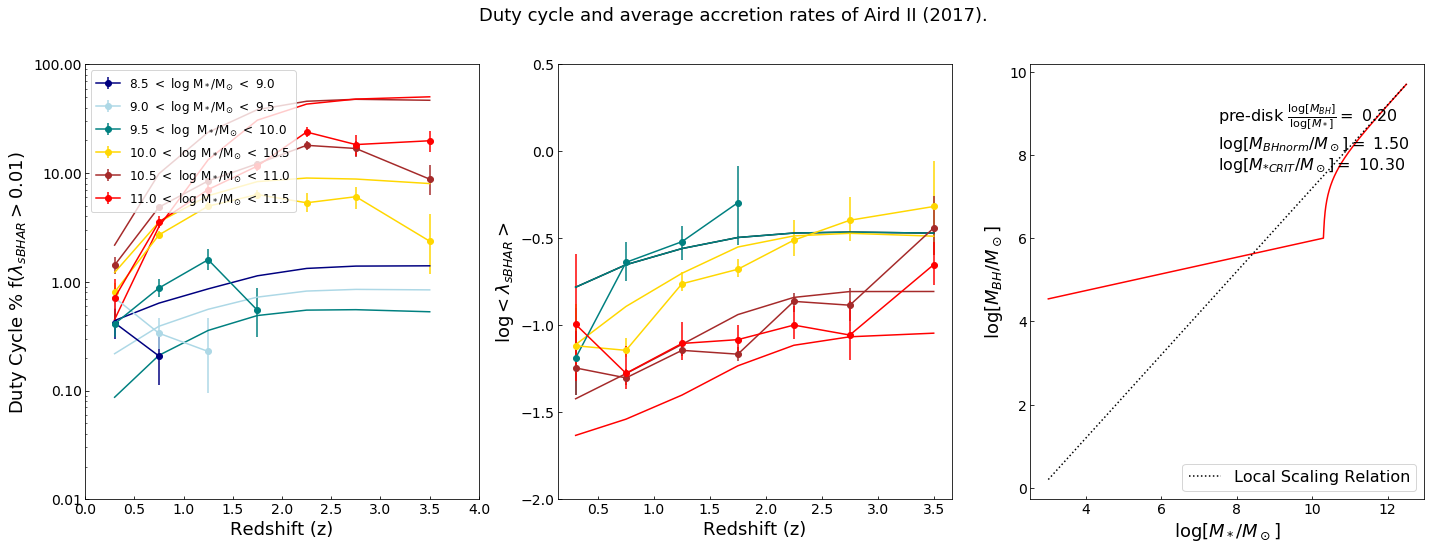

MovieWriter PillowWriter unavailable.


In [3]:
def plot_duty(slope_low, norm_from_local, Ms_crit, pre_SIG = False):

    f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
    chi23d = f['chi23d_grid'][:].T
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)

    bestpost = siglnX2[minind[0][0]]
    bestpre = siglnX1[minind[1][0]]
    bestcrit = logMstar0[minind[2][0]]


    duty_arid = open("plot_data/fduty_vs_z.dat",'r')
    all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

    for i in duty_arid.readlines():
        s = i.split()
        if s[0] == 'All':
            zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
            per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

    yerr = np.zeros([2,len(el)])
    yerr[0,:], yerr[1,:] = el, eh

    mass = [8.5,9.0,9.5,10.0,10.5,11.0]
    ztot = sorted(set((np.array(zl) + np.array(zh))/2))

    for i, c, l in zip(mass, colors, labels):
        ind = np.where(np.array(ml) == i)[0]
        z = (np.array(zl)[ind]+np.array(zh)[ind])/2
        dut = np.array(per)[ind]
        err = np.array(yerr)[:,ind]

        ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


    for c in ['teal', 'gold', 'brown', 'r']:
        x = []
        y = []
        yerrup = []
        yerrdown = []
        duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
        for i in duty_arid.readlines():
            s = i.split()
            if s[0][0] != '#' and s[0] == c:
                x.append(float(s[1]))
                y.append(float(s[2]))
                yerrup.append(float(s[3])-float(s[2]))
                yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
        yerr = np.zeros([2,len(yerrup)])
        yerr[0,:] = yerrdown
        yerr[1,:] = yerrup
        duty_arid.close()

        ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 
    
    pre, post, SIG_lnMs, b = bestpre, bestpost, 0.7, 0.005


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=True)
        if pre_SIG:
            qlf.get_dNdlnL(L, [pre_SIG, post])
        else:
            qlf.get_dNdlnL(L, [pre, post])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1
    
    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    ax3.plot(Mstar, Mbh, color='r')

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k')
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
        pcount+=1 
    
    

    
    ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax1.set_yscale('log')
    ax1.set_xlim([0, 4])
    ax1.set_ylim([0.01, 100])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax2.set_ylim([-2,0.5])
    ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

    ax3.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax3.plot(Mstar, Mstar-2.8,c='k',linestyle='dotted',label='Local Scaling Relation')






frames = 20
o_norm = 1.5
o_pre = 4.0
o_post = 2.5
slopes = list(np.linspace(o_slope,1.5,frames))
norms = list(np.linspace(o_norm,o_norm,frames))
crits = list(np.linspace(o_crit,o_crit,frames))
sigs = list(np.linspace(o_pre,o_pre,frames))

fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(24,8))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)

ax3.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
ax3.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)

camera = Camera(fig)
leg_count = 0

for s, n, m in zip(slopes,norms,crits):
    info = r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} =$ %.02f'%s
    info += '\n'+r'$\log[M_{BHnorm}/M_\odot] =$ %.02f'%n
    info += '\n'+r'$\log[M_{*CRIT}/M_\odot] =$ %.02f'%m
    
    fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
    plot_duty(s, n, m)
    if leg_count == 0:
        ax1.legend(fontsize = 12, loc='upper left')
        ax3.legend(loc='lower right',fontsize=16)
    leg_count += 1
    ax3.text(7.5,7.75,info,fontsize = 16)
    plt.pause(2)
    camera.snap()

animation = camera.animate()
animation.save('plots/new-param-plots/params_v_duty-slope.gif', writer='PillowWriter', fps=2)

DUTY PARAM PLOT: pre-disk slope (no loacl approx)

In [8]:
#no approx
def plot_duty(slope_low, norm_from_local, Ms_crit, pre_SIG = False):

    f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
    chi23d = f['chi23d_grid'][:].T
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)

    bestpost = siglnX2[minind[0][0]]
    bestpre = siglnX1[minind[1][0]]
    bestcrit = logMstar0[minind[2][0]]


    duty_arid = open("plot_data/fduty_vs_z.dat",'r')
    all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

    for i in duty_arid.readlines():
        s = i.split()
        if s[0] == 'All':
            zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
            per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

    yerr = np.zeros([2,len(el)])
    yerr[0,:], yerr[1,:] = el, eh

    mass = [8.5,9.0,9.5,10.0,10.5,11.0]
    ztot = sorted(set((np.array(zl) + np.array(zh))/2))

    for i, c, l in zip(mass, colors, labels):
        ind = np.where(np.array(ml) == i)[0]
        z = (np.array(zl)[ind]+np.array(zh)[ind])/2
        dut = np.array(per)[ind]
        err = np.array(yerr)[:,ind]

        ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


    for c in ['teal', 'gold', 'brown', 'r']:
        x = []
        y = []
        yerrup = []
        yerrdown = []
        duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
        for i in duty_arid.readlines():
            s = i.split()
            if s[0][0] != '#' and s[0] == c:
                x.append(float(s[1]))
                y.append(float(s[2]))
                yerrup.append(float(s[3])-float(s[2]))
                yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
        yerr = np.zeros([2,len(yerrup)])
        yerr[0,:] = yerrdown
        yerr[1,:] = yerrup
        duty_arid.close()

        ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 
    
    pre, post, SIG_lnMs, b = bestpre, bestpost, 0.7, 0.005


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=False)
        if pre_SIG:
            qlf.get_dNdlnL(L, [pre_SIG, post])
        else:
            qlf.get_dNdlnL(L, [pre, post])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1
    
    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    ax3.plot(Mstar, Mbh, color='r')

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k')
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
        pcount+=1 
    
    

    
    ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax1.set_yscale('log')
    ax1.set_xlim([0, 4])
    ax1.set_ylim([0.01, 100])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax2.set_ylim([-2,0.5])
    ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

    ax3.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax3.plot(Mstar, Mstar*1.12-11*1.12+8.2,c='k',linestyle='dotted',label='Local Scaling Relation')






frames = 20
slopes = list(np.linspace(o_slope,1.5,frames))
norms = list(np.linspace(o_norm,o_norm,frames))
crits = list(np.linspace(o_crit,o_crit,frames))
sigs = list(np.linspace(o_pre,o_pre,frames))

fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(24,8))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)

ax3.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
ax3.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)

camera = Camera(fig)
leg_count = 0

for s, n, m in zip(slopes,norms,crits):
    info = r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} =$ %.02f'%s
    info += '\n'+r'$\log[M_{BHnorm}/M_\odot] =$ %.02f'%n
    info += '\n'+r'$\log[M_{*CRIT}/M_\odot] =$ %.02f'%m
    
    fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
    plot_duty(s, n, m)
    if leg_count == 0:
        ax1.legend(fontsize = 12, loc='upper left')
        ax3.legend(loc='lower right',fontsize=16)
    leg_count += 1
    ax3.text(7.5,7.75,info,fontsize = 16)
    plt.pause(2)
    camera.snap()

animation = camera.animate()
animation.save('plots/new-param-plots/params_v_duty-slope-nolocalapprox.gif', writer='PillowWriter', fps=2)

FigureCanvasNbAgg()

MovieWriter PillowWriter unavailable.


DUTY PARAM PLOT: Mbh-norm

In [9]:
def plot_duty(slope_low, norm_from_local, Ms_crit, pre_SIG = False):

    f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
    chi23d = f['chi23d_grid'][:].T
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)

    bestpost = siglnX2[minind[0][0]]
    bestpre = siglnX1[minind[1][0]]
    bestcrit = logMstar0[minind[2][0]]


    duty_arid = open("plot_data/fduty_vs_z.dat",'r')
    all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

    for i in duty_arid.readlines():
        s = i.split()
        if s[0] == 'All':
            zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
            per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

    yerr = np.zeros([2,len(el)])
    yerr[0,:], yerr[1,:] = el, eh

    mass = [8.5,9.0,9.5,10.0,10.5,11.0]
    ztot = sorted(set((np.array(zl) + np.array(zh))/2))

    for i, c, l in zip(mass, colors, labels):
        ind = np.where(np.array(ml) == i)[0]
        z = (np.array(zl)[ind]+np.array(zh)[ind])/2
        dut = np.array(per)[ind]
        err = np.array(yerr)[:,ind]

        ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


    for c in ['teal', 'gold', 'brown', 'r']:
        x = []
        y = []
        yerrup = []
        yerrdown = []
        duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
        for i in duty_arid.readlines():
            s = i.split()
            if s[0][0] != '#' and s[0] == c:
                x.append(float(s[1]))
                y.append(float(s[2]))
                yerrup.append(float(s[3])-float(s[2]))
                yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
        yerr = np.zeros([2,len(yerrup)])
        yerr[0,:] = yerrdown
        yerr[1,:] = yerrup
        duty_arid.close()

        ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 
    
    pre, post, SIG_lnMs, b = bestpre, bestpost, 0.7, 0.005


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=True)
        if pre_SIG:
            qlf.get_dNdlnL(L, [pre_SIG, post])
        else:
            qlf.get_dNdlnL(L, [pre, post])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1
    
    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    ax3.plot(Mstar, Mbh, color='r')

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k')
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
        pcount+=1 
    
    

    
    ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax1.set_yscale('log')
    ax1.set_xlim([0, 4])
    ax1.set_ylim([0.01, 100])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax2.set_ylim([-2,0.5])
    ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

    ax3.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax3.plot(Mstar, Mstar-2.8,c='k',linestyle='dotted',label='Local Scaling Relation')






frames = 20
slopes = list(np.linspace(o_slope,o_slope,frames))
norms = list(np.linspace(o_norm,0,frames))
crits = list(np.linspace(o_crit,o_crit,frames))
sigs = list(np.linspace(o_pre,o_pre,frames))

fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(24,8))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)

ax3.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
ax3.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)

camera = Camera(fig)
leg_count = 0

for s, n, m in zip(slopes,norms,crits):
    info = r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} =$ %.02f'%s
    info += '\n'+r'$\log[M_{BHnorm}/M_\odot] =$ %.02f'%n
    info += '\n'+r'$\log[M_{*CRIT}/M_\odot] =$ %.02f'%m
    
    fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
    plot_duty(s, n, m)
    if leg_count == 0:
        ax1.legend(fontsize = 12, loc='upper left')
        ax3.legend(loc='lower right',fontsize=16)
    leg_count += 1
    ax3.text(7.5,7.75,info,fontsize = 16)
    plt.pause(2)
    camera.snap()

animation = camera.animate()
animation.save('plots/new-param-plots/params_v_duty-norm.gif', writer='PillowWriter', fps=2)

FigureCanvasNbAgg()

MovieWriter PillowWriter unavailable.


DUTY PARAM PLOT: Mstar-crit

In [10]:
def plot_duty(slope_low, norm_from_local, Ms_crit, pre_SIG = False):

    f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
    chi23d = f['chi23d_grid'][:].T
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)

    bestpost = siglnX2[minind[0][0]]
    bestpre = siglnX1[minind[1][0]]
    bestcrit = logMstar0[minind[2][0]]


    duty_arid = open("plot_data/fduty_vs_z.dat",'r')
    all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

    for i in duty_arid.readlines():
        s = i.split()
        if s[0] == 'All':
            zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
            per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

    yerr = np.zeros([2,len(el)])
    yerr[0,:], yerr[1,:] = el, eh

    mass = [8.5,9.0,9.5,10.0,10.5,11.0]
    ztot = sorted(set((np.array(zl) + np.array(zh))/2))

    for i, c, l in zip(mass, colors, labels):
        ind = np.where(np.array(ml) == i)[0]
        z = (np.array(zl)[ind]+np.array(zh)[ind])/2
        dut = np.array(per)[ind]
        err = np.array(yerr)[:,ind]

        ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


    for c in ['teal', 'gold', 'brown', 'r']:
        x = []
        y = []
        yerrup = []
        yerrdown = []
        duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
        for i in duty_arid.readlines():
            s = i.split()
            if s[0][0] != '#' and s[0] == c:
                x.append(float(s[1]))
                y.append(float(s[2]))
                yerrup.append(float(s[3])-float(s[2]))
                yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
        yerr = np.zeros([2,len(yerrup)])
        yerr[0,:] = yerrdown
        yerr[1,:] = yerrup
        duty_arid.close()

        ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 
    
    pre, post, SIG_lnMs, b = bestpre, bestpost, 0.7, 0.005


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=True)
        if pre_SIG:
            qlf.get_dNdlnL(L, [pre_SIG, post])
        else:
            qlf.get_dNdlnL(L, [pre, post])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1
    
    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    ax3.plot(Mstar, Mbh, color='r')

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k')
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
        pcount+=1 
    
    

    
    ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax1.set_yscale('log')
    ax1.set_xlim([0, 4])
    ax1.set_ylim([0.01, 100])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax2.set_ylim([-2,0.5])
    ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

    ax3.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax3.plot(Mstar, Mstar-2.8,c='k',linestyle='dotted',label='Local Scaling Relation')






frames = 20
slopes = list(np.linspace(o_slope,o_slope,frames))
norms = list(np.linspace(o_norm,o_norm,frames))
crits = list(np.linspace(8.5,11.7,frames))
sigs = list(np.linspace(o_pre,o_pre,frames))

fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(24,8))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)

ax3.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
ax3.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)

camera = Camera(fig)
leg_count = 0

for s, n, m in zip(slopes,norms,crits):
    info = r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} =$ %.02f'%s
    info += '\n'+r'$\log[M_{BHnorm}/M_\odot] =$ %.02f'%n
    info += '\n'+r'$\log[M_{*CRIT}/M_\odot] =$ %.02f'%m
    
    fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
    plot_duty(s, n, m)
    if leg_count == 0:
        ax1.legend(fontsize = 12, loc='upper left')
        ax3.legend(loc='lower right',fontsize=16)
    leg_count += 1
    ax3.text(7.5,7.75,info,fontsize = 16)
    plt.pause(2)
    camera.snap()

animation = camera.animate()
animation.save('plots/new-param-plots/params_v_duty-crits.gif', writer='PillowWriter', fps=2)

FigureCanvasNbAgg()

MovieWriter PillowWriter unavailable.


DUTY PARAM PLOT: pre-disk sigma

In [11]:
def plot_duty(slope_low, norm_from_local, Ms_crit, pre_SIG = False):

    f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
    chi23d = f['chi23d_grid'][:].T
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)

    bestpost = siglnX2[minind[0][0]]
    bestpre = siglnX1[minind[1][0]]
    bestcrit = logMstar0[minind[2][0]]


    duty_arid = open("plot_data/fduty_vs_z.dat",'r')
    all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

    for i in duty_arid.readlines():
        s = i.split()
        if s[0] == 'All':
            zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
            per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

    yerr = np.zeros([2,len(el)])
    yerr[0,:], yerr[1,:] = el, eh

    mass = [8.5,9.0,9.5,10.0,10.5,11.0]
    ztot = sorted(set((np.array(zl) + np.array(zh))/2))

    for i, c, l in zip(mass, colors, labels):
        ind = np.where(np.array(ml) == i)[0]
        z = (np.array(zl)[ind]+np.array(zh)[ind])/2
        dut = np.array(per)[ind]
        err = np.array(yerr)[:,ind]

        ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


    for c in ['teal', 'gold', 'brown', 'r']:
        x = []
        y = []
        yerrup = []
        yerrdown = []
        duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
        for i in duty_arid.readlines():
            s = i.split()
            if s[0][0] != '#' and s[0] == c:
                x.append(float(s[1]))
                y.append(float(s[2]))
                yerrup.append(float(s[3])-float(s[2]))
                yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
        yerr = np.zeros([2,len(yerrup)])
        yerr[0,:] = yerrdown
        yerr[1,:] = yerrup
        duty_arid.close()

        ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 
    
    pre, post, SIG_lnMs, b = bestpre, bestpost, 0.7, 0.005


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=True)
        if pre_SIG:
            qlf.get_dNdlnL(L, [pre_SIG, post])
        else:
            qlf.get_dNdlnL(L, [pre, post])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1
    
    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    ax3.plot(Mstar, Mbh, color='r')

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k')
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
        pcount+=1 
    
    

    
    ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax1.set_yscale('log')
    ax1.set_xlim([0, 4])
    ax1.set_ylim([0.01, 100])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax2.set_ylim([-2,0.5])
    ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

    ax3.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax3.plot(Mstar, Mstar-2.8,c='k',linestyle='dotted',label='Local Scaling Relation')










frames = 20
slopes = list(np.linspace(o_slope,o_slope,frames))
norms = list(np.linspace(o_norm,o_norm,frames))
crits = list(np.linspace(o_crit,o_crit,frames))
sigs = list(np.linspace(2,6,frames))

fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(24,8))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)

ax3.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
ax3.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)

camera = Camera(fig)
leg_count = 0

for s, n, m, sig in zip(slopes,norms,crits,sigs):
    info = r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} =$ %.02f'%s
    info += '\n'+r'$\log[M_{BHnorm}/M_\odot] =$ %.02f'%n
    info += '\n'+r'$\log[M_{*CRIT}/M_\odot] =$ %.02f'%m
    info += '\n'+r'pre-disk $\sigma_{\ln X } = $ %.02f'%sig
    
    fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
    plot_duty(s, n, m, sig)
    if leg_count == 0:
        ax1.legend(fontsize = 12, loc='upper left')
        ax3.legend(loc='lower right',fontsize=16)
    leg_count += 1
    ax3.text(7.5,7.75,info,fontsize = 16)
    plt.pause(2)
    camera.snap()

animation = camera.animate()
animation.save('plots/new-param-plots/params_v_duty-presig.gif', writer='PillowWriter', fps=2)

FigureCanvasNbAgg()

MovieWriter PillowWriter unavailable.


EXPLORE PLOT: explore parameters and how they fit, not approximating local slope

In [19]:
def plot_duty(slope_low, norm_from_local, Ms_crit, post_SIG = False):

    f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
    chi23d = f['chi23d_grid'][:].T
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)

    bestpost = siglnX2[minind[0][0]]
    bestpre = siglnX1[minind[1][0]]
    bestcrit = logMstar0[minind[2][0]]


    duty_arid = open("plot_data/fduty_vs_z.dat",'r')
    all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

    for i in duty_arid.readlines():
        s = i.split()
        if s[0] == 'All':
            zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
            per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

    yerr = np.zeros([2,len(el)])
    yerr[0,:], yerr[1,:] = el, eh

    mass = [8.5,9.0,9.5,10.0,10.5,11.0]
    ztot = sorted(set((np.array(zl) + np.array(zh))/2))

    for i, c, l in zip(mass, colors, labels):
        ind = np.where(np.array(ml) == i)[0]
        z = (np.array(zl)[ind]+np.array(zh)[ind])/2
        dut = np.array(per)[ind]
        err = np.array(yerr)[:,ind]

        ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


    for c in ['teal', 'gold', 'brown', 'r']:
        x = []
        y = []
        yerrup = []
        yerrdown = []
        duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
        for i in duty_arid.readlines():
            s = i.split()
            if s[0][0] != '#' and s[0] == c:
                x.append(float(s[1]))
                y.append(float(s[2]))
                yerrup.append(float(s[3])-float(s[2]))
                yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
        yerr = np.zeros([2,len(yerrup)])
        yerr[0,:] = yerrdown
        yerr[1,:] = yerrup
        duty_arid.close()

        ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 
    
    pre, post, SIG_lnMs, b = bestpre, bestpost, 0.7, 0.005


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=False)
        if post_SIG:
            qlf.get_dNdlnL(L, [pre, post_SIG])
        else:
            qlf.get_dNdlnL(L, [pre, post])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1
    
    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    ax3.plot(Mstar, Mbh, color='r')

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k')
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
        pcount+=1 
    
    

    
    ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax1.set_yscale('log')
    ax1.set_xlim([0, 4])
    ax1.set_ylim([0.01, 100])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax2.set_ylim([-2,0.5])
    ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

    ax3.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax3.plot(Mstar, Mstar*1.12-11*1.12+8.2,c='k',linestyle='dotted',label='Local Scaling Relation')


    
    
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(24,8))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']


ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)

ax3.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
ax3.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)
ax3.set_xlim([7,12.2])

fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
plt.savefig('test.pdf')
### solution 1 
slope, norm, mcrit, sig = .2, 4.0, 10.3, 2.6
### small slope exploration
# slope, norm, mcrit, sig = 0.2, 1.4, 10.4, 4.7
### how much can we flatten the slope?
# slope, norm, mcrit, sig = 1.0, 0, 10.2, 2.8
plot_duty(slope, norm, mcrit, sig)



FigureCanvasNbAgg()

PAPER PLOT: free param effects on QLF    

plotting for param crit = 9.3
plotting for param crit = 10.3
plotting for param crit = 11.3
plotting for param xsig1 = 3.3
plotting for param xsig1 = 4.3
plotting for param xsig1 = 5.3
plotting for param xsig2 = 0.7
plotting for param xsig2 = 1.7
plotting for param xsig2 = 2.7
plotting for param slope_low = 0.30000000000000004
plotting for param slope_low = 1.0
plotting for param slope_low = 1.7
plotting for param norm_from_local = 0.7
plotting for param norm_from_local = 1.4
plotting for param norm_from_local = 2.0999999999999996


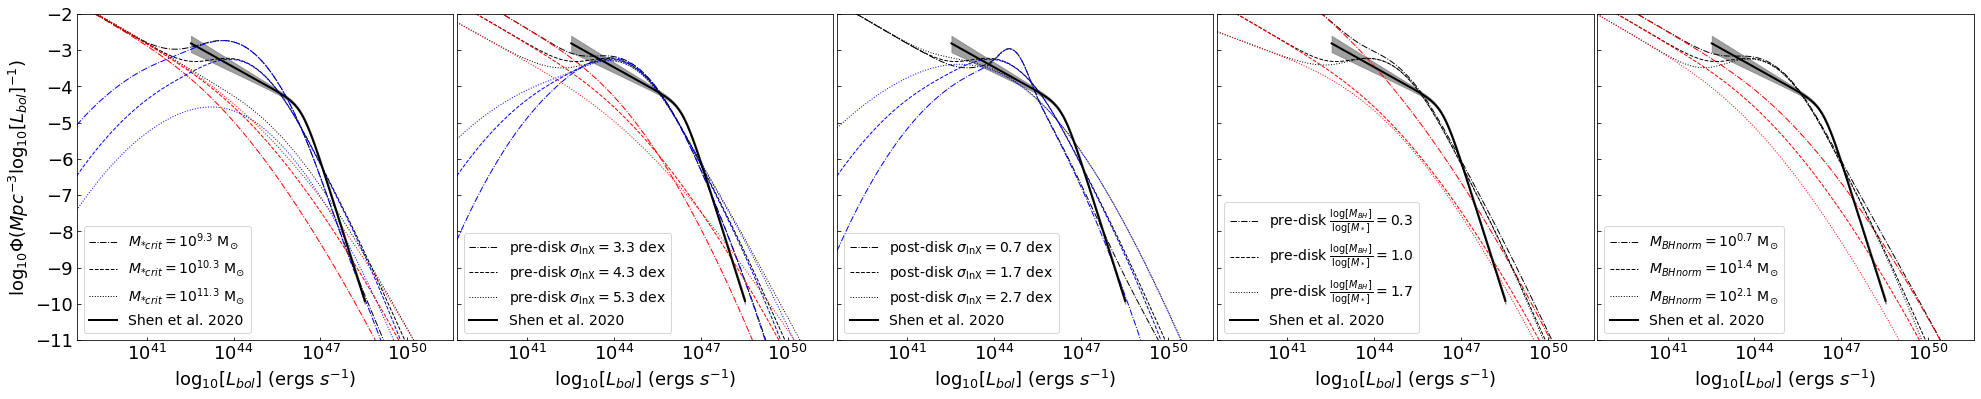

In [2]:
##### shows the effects of 

### setting up figure
fig = plt.figure(figsize=(34,6))
gs = gridspec.GridSpec(1, 5)
gs.update(wspace=0.01)

### setting up axes
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharex = ax0, sharey = ax0)
ax2 = fig.add_subplot(gs[0, 2], sharex = ax0, sharey = ax0)
ax3 = fig.add_subplot(gs[0, 3], sharex = ax0, sharey = ax0)
ax4 = fig.add_subplot(gs[0, 4], sharex = ax0, sharey = ax0)

### defining some lists to loop over later
lines = ['dashdot','dashed','dotted',(0,(5, 10))]
colors = ['el', 'el', 'l', 'e', 'e']
params = {'crit':1.0, 'xsig1':1.0, 'xsig2':1.0, 'slope_low':0.7, 'norm_from_local':0.7}
labels = [[r'$M_{*crit} = 10^{', '}$ M$_{\odot}$'], [r'pre-disk $\sigma_{\ln \rmX} = $', ' dex'], \
         [r'post-disk $\sigma_{\ln \rmX} = $', ' dex'], [r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} = $',''],\
         [r'$M_{BHnorm} = 10^{', '}$ M$_{\odot}$']]
axes = [ax0, ax1, ax2, ax3, ax4]

### defining function to make retreieveing different qlf data easier
def qlf_data(crit, xsig1, xsig2, slope_low, norm_from_local):
    qlf.get_Mbh(crit, slope_low, norm_from_local, approx_local=True)
    qlf.get_dNdlnL(lums, [xsig1, xsig2])

### defining different luminosity arrays for retrieveing data and plotting
lums = np.linspace(5,18,200)
lumsshen = np.linspace(8.95,14.95,200)
lumsp = 10**lums*3.8e33
lumss = 10**lumsshen*3.8e33

### retrieveing the QLF fit parameters
siglnM = 0.7
bins = 0.005
start = 10.3
siglnX = [4.3, 1.7]
norm = 1.4
slope = 1.0
lums = np.linspace(5,18,200)
z = 1.5

### initialize a QLF and get Hopkins obs data
qlf = QLF(z, bins)
qlf.get_dNdlnMstar(siglnM)
x, y , yerr = grab_obs(z)

### loop over different parameters
for param, ax, label, c in zip(params, axes, labels, colors):

    ### plot three different variations of the different parameters
    for i, ls in zip([-1, 0, 1], lines):

        ### redefine values and retreive data
        p = {'crit':start, 'xsig1':siglnX[0], 'xsig2':siglnX[1], 'slope_low':slope, 'norm_from_local':norm}
        p[param] += i*params[param]
        print('plotting for param '+str(param)+' = '+str(p[param]))
        qlf_data(**p)
#         if ax == ax0 and i == 0:
#             print(qlf.lnxsig_list)

        ### find the late and early lines
        xm, ym = lumsp, np.log10(qlf.dNdlnL * np.log(10))

        totearly = np.sum(qlf.intvals[:,qlf.pre], axis = 1)
        totlate = np.sum(qlf.intvals[:,qlf.post], axis = 1)

        ### plot
        ax.plot(xm, ym, c='k',lw=1, label=label[0]+'%.01f'%p[param]+label[1], ls=ls)
        if 'e' in c:
            ax.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r',lw=1, ls=ls) 
        if 'l' in c:
            ax.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b',lw=1, ls=ls) 

### retrieve Shen data
dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen)

### plot Shen data on all axes, and maybe the Hopkins
for ax in axes:
    ax.plot(lumss, dens, label='Shen et al. 2020',c='black',linestyle='solid',lw = 2)
    ax.fill_between(lumss, dens-stanab, dens+stanb, color='gray', alpha=.75)

    ### make plots look better
    ax.legend(fontsize=14)
    ax.set_xlabel(r'$\log_{10} [L_{bol}]$ (ergs $s^{-1}$)', fontsize=18)
    ax.axis([min(xm),max(xm),-11,-2])
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', direction='in', labelsize = 18)

### one y label since they share axes
ax0.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)

### make plots look nicer and save plot
plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
plt.setp(ax4.get_yticklabels(), visible=False)
plt.tight_layout()
plt.savefig('plots/new-param-plots/free_params_effects_mk2.pdf')
    
    

PAPER PLOT: stellar mass-black hole mass relation (no local approx)

In [6]:
#### creating the SM-BH relation plots with varying parameters
%matplotlib widget
fig = plt.figure(figsize=(16,5))
gs = gridspec.GridSpec(1, 3)


pre, post, SIG_lnMs, Ms_crit, b = 4.4, 1.7, 0.7, 10.3, 0.005
slope_low, norm_from_local = .2, 2
L = np.linspace(5,18,200)
z = 1.0
norm = [11, 8.2]
tw, tl = 1, 5
colors = ['green','teal','purple','blue']

ax = fig.add_subplot(gs[0, 0])
for n, c in zip([1.5,2.5,3.5,4.5], colors):

    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(Ms_crit, slope_low, n, approx_local=False)
    qlf.get_dNdlnL(L, [pre, post])

    Mbh = qlf.BHBins
    Mstar = qlf.StellBins

    plt.plot(10**Mstar, 10**Mbh, label = r'x = '+str(n),c=c)
    plt.xlabel(r'$M_*(M_\odot)$',fontsize = 14)
    plt.ylabel(r'$M_{BH}(M_\odot)$',fontsize = 14)
plt.plot(10**Mstar, 10**(Mstar*1.12-11*1.12+8.2),c='k',linestyle='dashed',label='Local approx.')
plt.legend()
plt.xscale('log')
plt.yscale('log')
ax.set_xlim((10**7, 10**12))
ax.set_ylim((10**2,10**9))

plt.tick_params(direction='in', width = tw, length = tl, right = True, labelsize = 12)
legend = plt.legend(title = r'$M_{BHnorm}(M_\odot) = 10^x$',fontsize = 12,loc='upper left')
plt.setp(legend.get_title(),fontsize=14)
    
ax = fig.add_subplot(gs[0, 1], sharex = ax, sharey = ax)
for s, c in zip([0.2, 0.5, 1.0, 1.5],colors):
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(Ms_crit, s, norm_from_local, approx_local=False)
    qlf.get_dNdlnL(L, [pre, post])

    Mbh = qlf.BHBins
    Mstar = qlf.StellBins

    plt.plot(10**Mstar, 10**Mbh, label = str(s), c=c)
    plt.xlabel(r'$M_*(M_\odot)$',fontsize = 14)
plt.plot(10**Mstar, 10**(Mstar*1.12-11*1.12+8.2),c='k',linestyle='dashed',label='Local approx.')
plt.legend()
plt.xscale('log')
plt.yscale('log')
ax.set_xlim((10**7, 10**12))
ax.set_ylim((10**2,10**9))

plt.tick_params(direction='in', width = tw, length = tl, right = True, labelsize = 12)
legend = plt.legend(title = r'Pre-disk $\log[M_{BH}]/\log[M_*] = $',fontsize = 12,loc='upper left')
plt.setp(legend.get_title(),fontsize=14)
plt.setp(ax.get_yticklabels(), visible=False)
plt.tight_layout()
    
ax = fig.add_subplot(gs[0, 2], sharex = ax, sharey = ax)
for m, c in zip([8, 9, 10, 11],colors):
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(m, slope_low, norm_from_local, approx_local=False)
    qlf.get_dNdlnL(L, [pre, post])

    Mbh = qlf.BHBins
    Mstar = qlf.StellBins

    plt.plot(10**Mstar, 10**Mbh, label = r'x = '+str(m), c=c)
    plt.xlabel(r'$M_*(M_\odot)$', fontsize = 14)

plt.plot(10**Mstar, 10**(Mstar*1.12-11*1.12+8.2),c='k',linestyle='dashed',label='Local approx.')
plt.xscale('log')
plt.yscale('log')
ax.set_xlim((10**7, 10**12))
ax.set_ylim((10**2,10**9))

err_abv = 10**(11-2.8) - 10**(11-2.8-norm_from_local/2)
err_blw = 10**(11-2.8-norm_from_local/2) - 10**(11-2.8-norm_from_local)
yval = 10**(11-2.8-norm_from_local/2)
plt.errorbar(10**11, yval, yerr = np.asarray([[err_blw],[err_abv]]), c='r', elinewidth = 3, capthick = 2, linestyle='dotted', capsize = 4, label = '$M_{BHnorm}(M_\odot)$',fmt='none',barsabove= True)
# plt.vlines(10**11, yval+err_abv, yval-err_blw, label = '$M_{BHnorm}(M_\odot)$', colors='r', linewidth = 2)

plt.tick_params(direction='in', width = tw, length = tl, right = True, labelsize = 12)
legend = plt.legend(title = r'$M_{*crit}(M_\odot) = 10^x$',fontsize = 12,loc='upper left')
plt.setp(legend.get_title(),fontsize=14)
plt.setp(ax.get_yticklabels(), visible=False)
plt.tight_layout()

plt.savefig('plots/FINAL_paper_plots/SMBH_SM_relation_mk2-nolocalapprox.pdf')

FigureCanvasNbAgg()

PAPER PLOT: stellar mass-black hole mass relation

In [7]:
#### creating the SM-BH relation plots with varying parameters
%matplotlib widget
fig = plt.figure(figsize=(16,5))
gs = gridspec.GridSpec(1, 3)


pre, post, SIG_lnMs, Ms_crit, b = 4.4, 1.7, 0.7, 10.3, 0.005
slope_low, norm_from_local = .2, 2
L = np.linspace(5,18,200)
z = 1.0
norm = [11, 8.2]
tw, tl = 1, 5
colors = ['green','teal','purple','blue']

ax = fig.add_subplot(gs[0, 0])
for n, c in zip([1.5,2.5,3.5,4.5], colors):

    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(Ms_crit, slope_low, n, approx_local=True)
    qlf.get_dNdlnL(L, [pre, post])

    Mbh = qlf.BHBins
    Mstar = qlf.StellBins

    plt.plot(10**Mstar, 10**Mbh, label = r'x = '+str(n),c=c)
    plt.xlabel(r'$M_*(M_\odot)$',fontsize = 14)
    plt.ylabel(r'$M_{BH}(M_\odot)$',fontsize = 14)
plt.plot(10**Mstar, 10**(Mstar-2.8),c='k',linestyle='dashed',label='Local approx.')
plt.legend()
plt.xscale('log')
plt.yscale('log')
ax.set_xlim((10**7, 10**12))
ax.set_ylim((10**2,10**9))

plt.tick_params(direction='in', width = tw, length = tl, right = True, labelsize = 12)
legend = plt.legend(title = r'$M_{BHnorm}(M_\odot) = 10^x$',fontsize = 12,loc='upper left')
plt.setp(legend.get_title(),fontsize=14)
    
ax = fig.add_subplot(gs[0, 1], sharex = ax, sharey = ax)
for s, c in zip([0.2, 0.5, 1.0, 1.5],colors):
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(Ms_crit, s, norm_from_local, approx_local=False)
    qlf.get_dNdlnL(L, [pre, post])

    Mbh = qlf.BHBins
    Mstar = qlf.StellBins

    plt.plot(10**Mstar, 10**Mbh, label = str(s), c=c)
    plt.xlabel(r'$M_*(M_\odot)$',fontsize = 14)
plt.plot(10**Mstar, 10**(Mstar-2.8),c='k',linestyle='dashed',label='Local approx.')
plt.legend()
plt.xscale('log')
plt.yscale('log')
ax.set_xlim((10**7, 10**12))
ax.set_ylim((10**2,10**9))

plt.tick_params(direction='in', width = tw, length = tl, right = True, labelsize = 12)
legend = plt.legend(title = r'Pre-disk $\log[M_{BH}]/\log[M_*] = $',fontsize = 12,loc='upper left')
plt.setp(legend.get_title(),fontsize=14)
plt.setp(ax.get_yticklabels(), visible=False)
plt.tight_layout()
    
ax = fig.add_subplot(gs[0, 2], sharex = ax, sharey = ax)
for m, c in zip([8, 9, 10, 11],colors):
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(m, slope_low, norm_from_local, approx_local=False)
    qlf.get_dNdlnL(L, [pre, post])

    Mbh = qlf.BHBins
    Mstar = qlf.StellBins

    plt.plot(10**Mstar, 10**Mbh, label = r'x = '+str(m), c=c)
    plt.xlabel(r'$M_*(M_\odot)$', fontsize = 14)

plt.plot(10**Mstar, 10**(Mstar-2.8),c='k',linestyle='dashed',label='Local approx.')
plt.xscale('log')
plt.yscale('log')
ax.set_xlim((10**7, 10**12))
ax.set_ylim((10**2,10**9))

err_abv = 10**(11-2.8) - 10**(11-2.8-norm_from_local/2)
err_blw = 10**(11-2.8-norm_from_local/2) - 10**(11-2.8-norm_from_local)
yval = 10**(11-2.8-norm_from_local/2)
plt.errorbar(10**11, yval, yerr = np.asarray([[err_blw],[err_abv]]), c='r', elinewidth = 3, capthick = 2, linestyle='dotted', capsize = 4, label = '$M_{BHnorm}(M_\odot)$',fmt='none',barsabove= True)
# plt.vlines(10**11, yval+err_abv, yval-err_blw, label = '$M_{BHnorm}(M_\odot)$', colors='r', linewidth = 2)

plt.tick_params(direction='in', width = tw, length = tl, right = True, labelsize = 12)
legend = plt.legend(title = r'$M_{*crit}(M_\odot) = 10^x$',fontsize = 12,loc='upper left')
plt.setp(legend.get_title(),fontsize=14)
plt.setp(ax.get_yticklabels(), visible=False)
plt.tight_layout()

plt.savefig('plots/FINAL_paper_plots/SMBH_SM_relation_mk2.pdf')

FigureCanvasNbAgg()

DUTY PARAM PLOT: post-disk sigma

In [12]:
###### explore param effects of post-disk sig
def plot_duty(slope_low, norm_from_local, Ms_crit, post_SIG = False):

    f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
    chi23d = f['chi23d_grid'][:].T
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)

    bestpost = siglnX2[minind[0][0]]
    bestpre = siglnX1[minind[1][0]]
    bestcrit = logMstar0[minind[2][0]]


    duty_arid = open("plot_data/fduty_vs_z.dat",'r')
    all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

    for i in duty_arid.readlines():
        s = i.split()
        if s[0] == 'All':
            zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
            per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

    yerr = np.zeros([2,len(el)])
    yerr[0,:], yerr[1,:] = el, eh

    mass = [8.5,9.0,9.5,10.0,10.5,11.0]
    ztot = sorted(set((np.array(zl) + np.array(zh))/2))

    for i, c, l in zip(mass, colors, labels):
        ind = np.where(np.array(ml) == i)[0]
        z = (np.array(zl)[ind]+np.array(zh)[ind])/2
        dut = np.array(per)[ind]
        err = np.array(yerr)[:,ind]

        ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


    for c in ['teal', 'gold', 'brown', 'r']:
        x = []
        y = []
        yerrup = []
        yerrdown = []
        duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
        for i in duty_arid.readlines():
            s = i.split()
            if s[0][0] != '#' and s[0] == c:
                x.append(float(s[1]))
                y.append(float(s[2]))
                yerrup.append(float(s[3])-float(s[2]))
                yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
        yerr = np.zeros([2,len(yerrup)])
        yerr[0,:] = yerrdown
        yerr[1,:] = yerrup
        duty_arid.close()

        ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 
    
    pre, post, SIG_lnMs, b = bestpre, bestpost, 0.7, 0.005


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=True)
        if post_SIG:
            qlf.get_dNdlnL(L, [pre, post_SIG])
        else:
            qlf.get_dNdlnL(L, [pre, post])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1
    
    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    ax3.plot(Mstar, Mbh, color='r')

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k')
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
        pcount+=1 
    
    
    
    

    
    ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax1.set_yscale('log')
    ax1.set_xlim([0, 4])
    ax1.set_ylim([0.01, 100])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax2.set_ylim([-2,0.5])
    ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

    ax3.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax3.plot(Mstar, Mstar-2.8,c='k',linestyle='dotted',label='Local Scaling Relation')


frames = 20
slopes = list(np.linspace(o_slope,o_slope,frames))
norms = list(np.linspace(o_norm,o_norm,frames))
crits = list(np.linspace(o_crit,o_crit,frames))
sigs = list(np.linspace(1.5,5.5,frames))

fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(24,8))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)

ax3.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
ax3.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)

camera = Camera(fig)
leg_count = 0

for s, n, m, sig in zip(slopes,norms,crits,sigs):
    info = r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} =$ %.02f'%s
    info += '\n'+r'$\log[M_{BHnorm}/M_\odot] =$ %.02f'%n
    info += '\n'+r'$\log[M_{*CRIT}/M_\odot] =$ %.02f'%m
    info += '\n'+r'post-disk $\sigma_{\ln X } = $ %.02f'%sig
    
    fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
    plot_duty(s, n, m, sig)
    if leg_count == 0:
        ax1.legend(fontsize = 12, loc='upper left')
        ax3.legend(loc='lower right',fontsize=16)
    leg_count += 1
    ax3.text(7.5,7.75,info,fontsize = 16)
    plt.pause(2)
    camera.snap()

animation = camera.animate()
animation.save('plots/new-param-plots/params_v_duty-postsig.gif', writer='PillowWriter', fps=2)

FigureCanvasNbAgg()

MovieWriter PillowWriter unavailable.


DUTY PARAM PLOT BEST FIT: norm

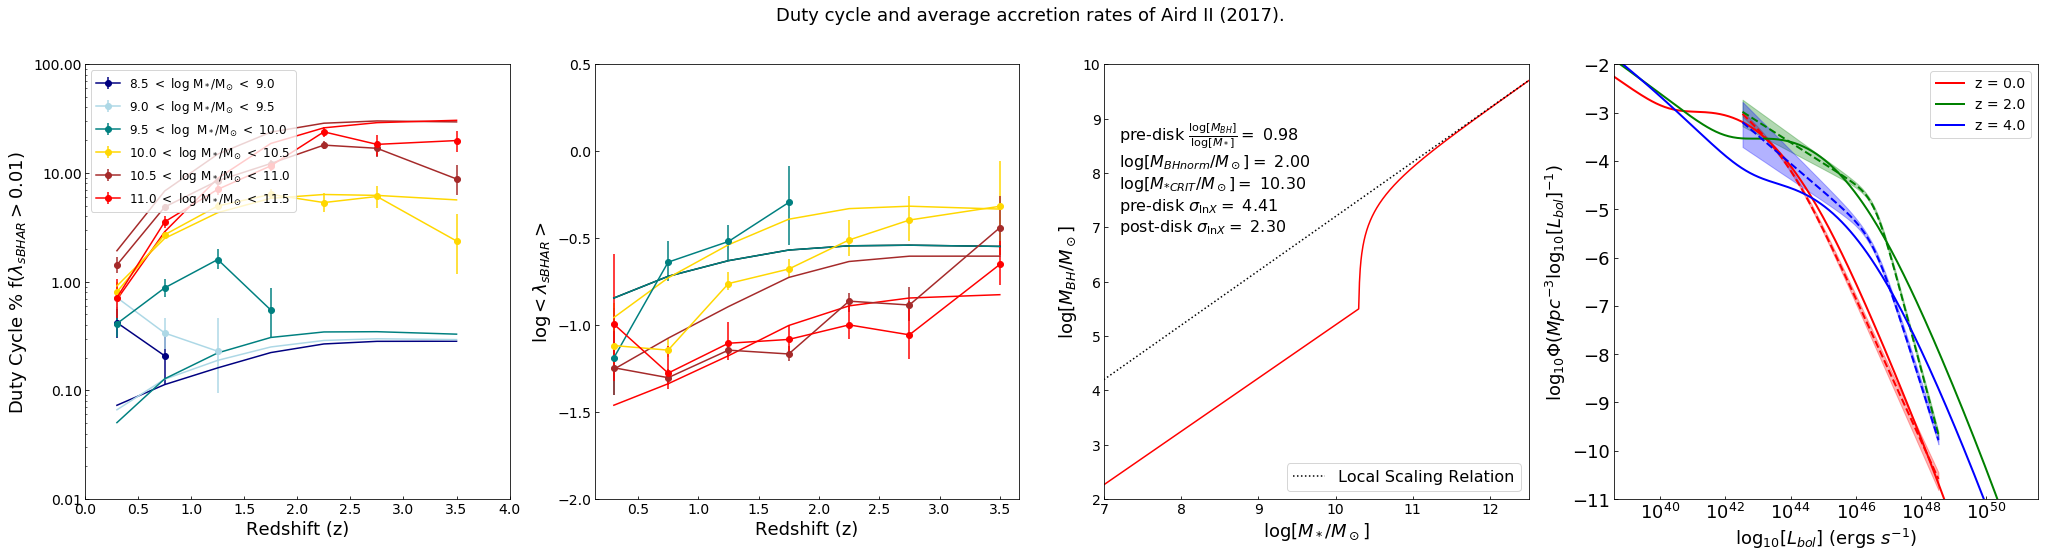

MovieWriter PillowWriter unavailable.


In [14]:
###### explore param effects of post-disk sig
def plot_duty(slope_low, norm_from_local, Ms_crit):

    f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
    chi23d = f['chi23d_grid'][:].T
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)

    bestpost = siglnX2[minind[0][0]]
    bestpre = siglnX1[minind[1][0]]
    bestcrit = logMstar0[minind[2][0]]


    duty_arid = open("plot_data/fduty_vs_z.dat",'r')
    all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

    for i in duty_arid.readlines():
        s = i.split()
        if s[0] == 'All':
            zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
            per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

    yerr = np.zeros([2,len(el)])
    yerr[0,:], yerr[1,:] = el, eh

    mass = [8.5,9.0,9.5,10.0,10.5,11.0]
    ztot = sorted(set((np.array(zl) + np.array(zh))/2))

    for i, c, l in zip(mass, colors, labels):
        ind = np.where(np.array(ml) == i)[0]
        z = (np.array(zl)[ind]+np.array(zh)[ind])/2
        dut = np.array(per)[ind]
        err = np.array(yerr)[:,ind]

        ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


    for c in ['teal', 'gold', 'brown', 'r']:
        x = []
        y = []
        yerrup = []
        yerrdown = []
        duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
        for i in duty_arid.readlines():
            s = i.split()
            if s[0][0] != '#' and s[0] == c:
                x.append(float(s[1]))
                y.append(float(s[2]))
                yerrup.append(float(s[3])-float(s[2]))
                yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
        yerr = np.zeros([2,len(yerrup)])
        yerr[0,:] = yerrdown
        yerr[1,:] = yerrup
        duty_arid.close()

        ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 
    
    pre, post, SIG_lnMs, b = bestpre, bestpost, 0.7, 0.005


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=True)
        qlf.get_dNdlnL(L, [presig, postsig])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1
    
    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    ax3.plot(Mstar, Mbh, color='r')

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k')
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
        pcount+=1 
    
    
    
    

    
    ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax1.set_yscale('log')
    ax1.set_xlim([0, 4])
    ax1.set_ylim([0.01, 100])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax2.set_ylim([-2,0.5])
    ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

    ax3.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax3.plot(Mstar, Mstar-2.8,c='k',linestyle='dotted',label='Local Scaling Relation')
    ax3.set_xlim([7,12.5])
    ax3.set_ylim([2,10])
    
def plot_QLF(ax, color, z, crit, xsig1, xsig2, slope, norm):
    lums = np.linspace(5,18,200)
    lumsshen = np.linspace(8.95,14.95,200)
    lumsp = 10**lums*3.8e33
    lumss = 10**lumsshen*3.8e33
    
    qlf = QLF(z, 0.005)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(crit, slope, norm, approx_local=True)
    qlf.get_dNdlnL(lums, [xsig1, xsig2])
    xm, ym = lumsp, np.log10(qlf.dNdlnL * np.log(10))

    
    ax.plot(xm, ym, c=color,lw=2, ls='solid', label='z = '+str(z))
    
    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen)
    ax.plot(lumss, dens, c=color, linestyle='dashed',lw = 2)
    ax.fill_between(lumss, dens-stanab, dens+stanb, color=color, alpha=.3)
    
    ax.axis([min(xm),max(xm),-11,-2])
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', direction='in', labelsize = 18)

    
norm = 0.93
presig = 4.41
slope = 0.98 
crit = 10.3 
postsig = 2.3

frames = 20
slopes = list(np.linspace(slope,slope,frames))
norms = list(np.linspace(2,0,frames))
crits = list(np.linspace(crit,crit,frames))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(35,8))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)

ax3.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
ax3.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)

ax4.set_xlabel(r'$\log_{10} [L_{bol}]$ (ergs $s^{-1}$)', fontsize=18)
ax4.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)

camera = Camera(fig)
leg_count = 0

for s, n, m in zip(slopes, norms, crits):
    info = r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} =$ %.02f'%s
    info += '\n'+r'$\log[M_{BHnorm}/M_\odot] =$ %.02f'%n
    info += '\n'+r'$\log[M_{*CRIT}/M_\odot] =$ %.02f'%m
    info += '\n'+r'pre-disk $\sigma_{\ln X } = $ %.02f'%presig
    info += '\n'+r'post-disk $\sigma_{\ln X } = $ %.02f'%postsig
    
    fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
    plot_duty(s, n, m)
    for z, color in zip([0.0,2.0,4.0],['r','g','b']):
        plot_QLF(ax4, color, z, m, presig, postsig, s, n)
    if leg_count == 0:
        ax1.legend(fontsize = 12, loc='upper left')
        ax3.legend(loc='lower right',fontsize=16)
        ax4.legend(fontsize=14)
    leg_count += 1
    ax3.text(7.2,7,info,fontsize = 16)
    
    plt.pause(2)
    camera.snap()

animation = camera.animate()
animation.save('plots/new-param-plots/best_fit_preview_NW_vary-norm.gif', writer='PillowWriter', fps=2)

# DUTY PARAM PLOT BEST FIT: slope

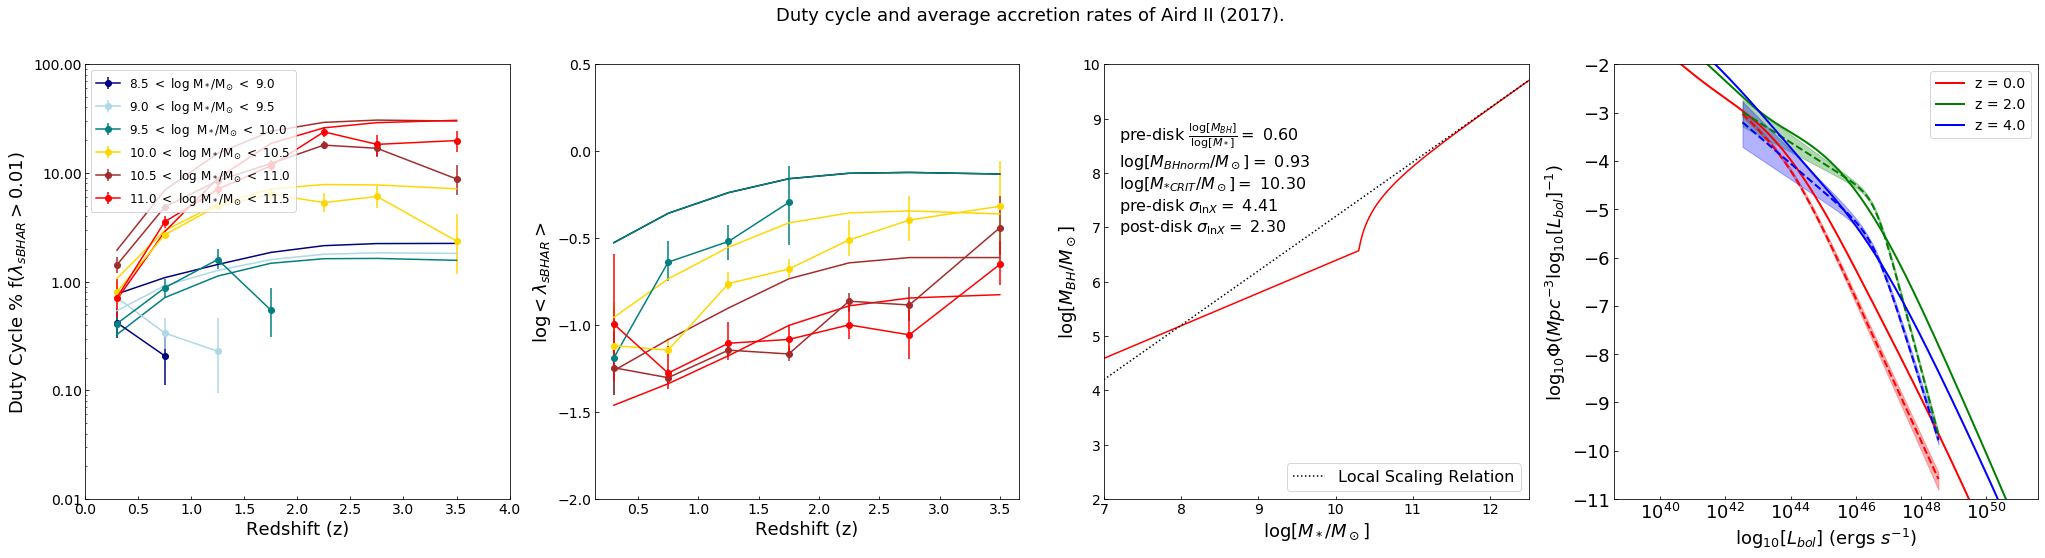

MovieWriter PillowWriter unavailable.


In [15]:
###### explore param effects of post-disk sig
def plot_duty(slope_low, norm_from_local, Ms_crit):

    f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
    chi23d = f['chi23d_grid'][:].T
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)

    bestpost = siglnX2[minind[0][0]]
    bestpre = siglnX1[minind[1][0]]
    bestcrit = logMstar0[minind[2][0]]


    duty_arid = open("plot_data/fduty_vs_z.dat",'r')
    all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

    for i in duty_arid.readlines():
        s = i.split()
        if s[0] == 'All':
            zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
            per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

    yerr = np.zeros([2,len(el)])
    yerr[0,:], yerr[1,:] = el, eh

    mass = [8.5,9.0,9.5,10.0,10.5,11.0]
    ztot = sorted(set((np.array(zl) + np.array(zh))/2))

    for i, c, l in zip(mass, colors, labels):
        ind = np.where(np.array(ml) == i)[0]
        z = (np.array(zl)[ind]+np.array(zh)[ind])/2
        dut = np.array(per)[ind]
        err = np.array(yerr)[:,ind]

        ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


    for c in ['teal', 'gold', 'brown', 'r']:
        x = []
        y = []
        yerrup = []
        yerrdown = []
        duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
        for i in duty_arid.readlines():
            s = i.split()
            if s[0][0] != '#' and s[0] == c:
                x.append(float(s[1]))
                y.append(float(s[2]))
                yerrup.append(float(s[3])-float(s[2]))
                yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
        yerr = np.zeros([2,len(yerrup)])
        yerr[0,:] = yerrdown
        yerr[1,:] = yerrup
        duty_arid.close()

        ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 
    
    pre, post, SIG_lnMs, b = bestpre, bestpost, 0.7, 0.005


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=True)
        qlf.get_dNdlnL(L, [presig, postsig])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1
    
    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    ax3.plot(Mstar, Mbh, color='r')

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k')
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
        pcount+=1 
    
    
    
    

    
    ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax1.set_yscale('log')
    ax1.set_xlim([0, 4])
    ax1.set_ylim([0.01, 100])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax2.set_ylim([-2,0.5])
    ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

    ax3.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax3.plot(Mstar, Mstar-2.8,c='k',linestyle='dotted',label='Local Scaling Relation')
    ax3.set_xlim([7,12.5])
    ax3.set_ylim([2,10])
    
def plot_QLF(ax, color, z, crit, xsig1, xsig2, slope, norm):
    lums = np.linspace(5,18,200)
    lumsshen = np.linspace(8.95,14.95,200)
    lumsp = 10**lums*3.8e33
    lumss = 10**lumsshen*3.8e33
    
    qlf = QLF(z, 0.005)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(crit, slope, norm, approx_local=True)
    qlf.get_dNdlnL(lums, [xsig1, xsig2])
    xm, ym = lumsp, np.log10(qlf.dNdlnL * np.log(10))

    
    ax.plot(xm, ym, c=color,lw=2, ls='solid', label='z = '+str(z))
    
    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen)
    ax.plot(lumss, dens, c=color, linestyle='dashed',lw = 2)
    ax.fill_between(lumss, dens-stanab, dens+stanb, color=color, alpha=.3)
    
    ax.axis([min(xm),max(xm),-11,-2])
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', direction='in', labelsize = 18)

    
norm = 0.93
presig = 4.41
slope = 0.98 
crit = 10.3 
postsig = 2.3

frames = 20
slopes = list(np.linspace(0.6,slope,frames))
norms = list(np.linspace(norm,norm,frames))
crits = list(np.linspace(crit,crit,frames))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(35,8))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)

ax3.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
ax3.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)

ax4.set_xlabel(r'$\log_{10} [L_{bol}]$ (ergs $s^{-1}$)', fontsize=18)
ax4.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)

camera = Camera(fig)
leg_count = 0

for s, n, m in zip(slopes, norms, crits):
    info = r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} =$ %.02f'%s
    info += '\n'+r'$\log[M_{BHnorm}/M_\odot] =$ %.02f'%n
    info += '\n'+r'$\log[M_{*CRIT}/M_\odot] =$ %.02f'%m
    info += '\n'+r'pre-disk $\sigma_{\ln X } = $ %.02f'%presig
    info += '\n'+r'post-disk $\sigma_{\ln X } = $ %.02f'%postsig
    
    fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
    plot_duty(s, n, m)
    for z, color in zip([0.0,2.0,4.0],['r','g','b']):
        plot_QLF(ax4, color, z, m, presig, postsig, s, n)
    if leg_count == 0:
        ax1.legend(fontsize = 12, loc='upper left')
        ax3.legend(loc='lower right',fontsize=16)
        ax4.legend(fontsize=14)
    leg_count += 1
    ax3.text(7.2,7,info,fontsize = 16)
    
    plt.pause(2)
    camera.snap()

animation = camera.animate()
animation.save('plots/new-param-plots/best_fit_preview_NW_vary-slope.gif', writer='PillowWriter', fps=2)

10.58 0.0 0.75
10.58 0.0 0.75
10.58 0.0 0.75
10.58 0.0 0.75
10.58 0.0 0.75
10.58 0.0 0.75
10.58 0.0 0.75


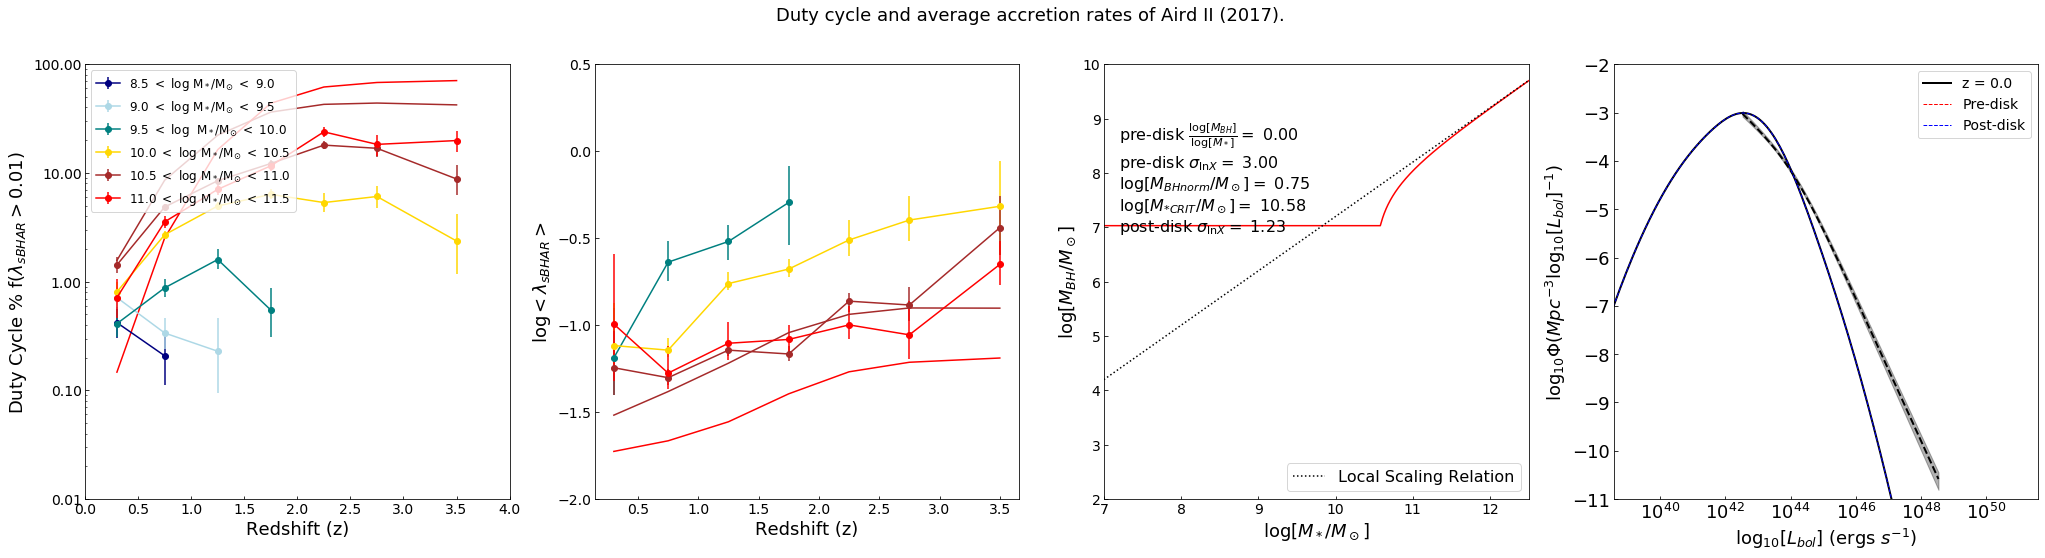

10.58 0.1 0.75
10.58 0.1 0.75
10.58 0.1 0.75
10.58 0.1 0.75
10.58 0.1 0.75
10.58 0.1 0.75
10.58 0.1 0.75
10.58 0.2 0.75
10.58 0.2 0.75
10.58 0.2 0.75
10.58 0.2 0.75
10.58 0.2 0.75
10.58 0.2 0.75
10.58 0.2 0.75
10.58 0.3 0.75
10.58 0.3 0.75
10.58 0.3 0.75
10.58 0.3 0.75
10.58 0.3 0.75
10.58 0.3 0.75
10.58 0.3 0.75
10.58 0.4 0.75
10.58 0.4 0.75
10.58 0.4 0.75
10.58 0.4 0.75
10.58 0.4 0.75
10.58 0.4 0.75
10.58 0.4 0.75
10.58 0.5 0.75
10.58 0.5 0.75
10.58 0.5 0.75
10.58 0.5 0.75
10.58 0.5 0.75
10.58 0.5 0.75
10.58 0.5 0.75
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 0.65
10.58 0.3 

MovieWriter PillowWriter unavailable.


In [22]:
###### explore param effects of post-disk sig
def plot_duty(slope_low, norm_from_local, Ms_crit, sigs):

    duty_arid = open("plot_data/fduty_vs_z.dat",'r')
    all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

    for i in duty_arid.readlines():
        s = i.split()
        if s[0] == 'All':
            zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
            per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

    yerr = np.zeros([2,len(el)])
    yerr[0,:], yerr[1,:] = el, eh

    mass = [8.5,9.0,9.5,10.0,10.5,11.0]
    ztot = sorted(set((np.array(zl) + np.array(zh))/2))

    for i, c, l in zip(mass, colors, labels):
        ind = np.where(np.array(ml) == i)[0]
        z = (np.array(zl)[ind]+np.array(zh)[ind])/2
        dut = np.array(per)[ind]
        err = np.array(yerr)[:,ind]

        ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


    for c in ['teal', 'gold', 'brown', 'r']:
        x = []
        y = []
        yerrup = []
        yerrdown = []
        duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
        for i in duty_arid.readlines():
            s = i.split()
            if s[0][0] != '#' and s[0] == c:
                x.append(float(s[1]))
                y.append(float(s[2]))
                yerrup.append(float(s[3])-float(s[2]))
                yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
        yerr = np.zeros([2,len(yerrup)])
        yerr[0,:] = yerrdown
        yerr[1,:] = yerrup
        duty_arid.close()

        ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 
    
    SIG_lnMs, b = 0.7, 0.005


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=True)
        qlf.get_dNdlnL(L, sigs)

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1
    
    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    ax3.plot(Mstar, Mbh, color='r')

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k')
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
        pcount+=1 
    
    
    ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax1.set_yscale('log')
    ax1.set_xlim([0, 4])
    ax1.set_ylim([0.01, 100])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax2.set_ylim([-2,0.5])
    ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

    ax3.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax3.plot(Mstar, Mstar-2.8,c='k',linestyle='dotted',label='Local Scaling Relation')
    ax3.set_xlim([7,12.5])
    ax3.set_ylim([2,10])
    
def plot_QLF(ax, color, z, crit, xsig1, xsig2, slope, norm):
    lums = np.linspace(5,18,200)
    lumsshen = np.linspace(8.95,14.95,200)
    lumsp = 10**lums*3.8e33
    lumss = 10**lumsshen*3.8e33
    
    qlf = QLF(z, 0.005)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(crit, slope, norm, approx_local=True)
    qlf.get_dNdlnL(lums, [xsig1, xsig2])
    xm, ym = lumsp, np.log10(qlf.dNdlnL * np.log(10))
    
    ax.plot(xm, ym, c=color,lw=2, ls='solid', label='z = '+str(z))
    
    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen)
    ax.plot(lumss, dens, c=color, linestyle='dashed',lw = 2)
    ax.fill_between(lumss, dens-stanab, dens+stanb, color=color, alpha=.3)
    
    totearly = np.sum(qlf.intvals[:,qlf.pre], axis = 1)
    totlate = np.sum(qlf.intvals[:,qlf.post], axis = 1)

    ax.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r',lw=1, ls='dashed', label='Pre-disk') 
    ax.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b',lw=1, ls='dashed', label='Post-disk') 
    
    ax.axis([min(xm),max(xm),-11,-2])
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', direction='in', labelsize = 18)

    
crit = 10.58
postsig = 1.23

frames = 13
slopes = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.31]
presigs = [3, 3, 3, 3, 3, 3, 3, 4, 5, 6, 7, 8, 5.03]
norms = [0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.65, 0.65, 0.65, 0.65, 0.65, 0.65, 2.79]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4,figsize=(35,8))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)

ax3.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
ax3.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)

ax4.set_xlabel(r'$\log_{10} [L_{bol}]$ (ergs $s^{-1}$)', fontsize=18)
ax4.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)

camera = Camera(fig)
leg_count = 0

for s, p, n in zip(slopes, presigs, norms):
    info = r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} =$ %.02f'%s
    info += '\n'+r'pre-disk $\sigma_{\ln X } = $ %.02f'%p
    info += '\n'+r'$\log[M_{BHnorm}/M_\odot] =$ %.02f'%n
    info += '\n'+r'$\log[M_{*CRIT}/M_\odot] =$ %.02f'%crit
    info += '\n'+r'post-disk $\sigma_{\ln X } = $ %.02f'%postsig
    
    fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
    plot_duty(slope_low = s, norm_from_local = n, Ms_crit = crit, sigs = [p, postsig])
    plot_QLF(ax4, 'k', 0.0, crit, p, postsig, s, n)
    if leg_count == 0:
        ax1.legend(fontsize = 12, loc='upper left')
        ax3.legend(loc='lower right',fontsize=16)
        ax4.legend(fontsize=14)
    leg_count += 1
    ax3.text(7.2,7,info,fontsize = 16)
    
    plt.pause(2)
    camera.snap()

animation = camera.animate()
animation.save('plots/new-param-plots/Shen_fit_gaps-z0.gif', writer='PillowWriter', fps=1)